In [1]:
from astropy.io import fits
import numpy as np 
import matplotlib.pyplot as plt
from astropy.table import Table
import os.path
from astropy.stats import median_absolute_deviation as mad
import warnings
from astropy.utils.exceptions import AstropyUserWarning
import ipympl
from astropy import units as u

from scipy.optimize import curve_fit
import pyneb as pn
from astropy.stats import median_absolute_deviation as mad
from scipy.interpolate import RegularGridInterpolator
from astropy.coordinates import SkyCoord
from dust_extinction.parameter_averages import F99
from dust_extinction.parameter_averages import G23

# To resize the color bar same as the maps
from mpl_toolkits.axes_grid1 import make_axes_locatable

from astropy.coordinates import SkyCoord

# Making x and y ticks more readable
from matplotlib.ticker import MaxNLocator   

In [2]:
%matplotlib widget
warnings.filterwarnings('ignore', category=AstropyUserWarning)


In [3]:
#3: {'mjdlist': [60188, 60191], 'expnumlist': [4160, 4285]},
#4: {'mjdlist': [60191, 60191], 'expnumlist': [4289, 4291]},

In [4]:
# Creating  spatially resolved Rv and ebv arrays

In [5]:
def pyneb_ratio(Te, ne):

    atom = pn.RecAtom('H', 1)

    wavelengths = [3750.15, 3770.63, 3835.38, 4101.74, 4340.463, 4861.32, 6563.0, 8862.78, 9014.91, 9229.01]

    # Initialize arrays for emissivities and ratios
    emis = np.zeros_like(wavelengths)  
    ratios = np.zeros_like(wavelengths)

    # Calculate emissivity for each wavelength and store it in the emis list
    for k, wl in enumerate(wavelengths):
        emis[k] = atom.getEmissivity(tem=Te, den=ne, wave=wl)

    #  Calculate the ratio of each emissivity w.r.t. the first one (emis[0])
    for n in range(0, len(wavelengths)):  
        ratios[n] = emis[n] /emis[5]
    ratios[5] = 1
    
    return ratios

pyneb_ratio(8100, 110)

array([0.03032939, 0.03942174, 0.07247722, 0.25677441, 0.4654372 ,
       1.        , 2.91252112, 0.01405938, 0.01879119, 0.02595263])

In [5]:
base_dir = '/Volumes/amrita/LVM/m8_oct30_25_final_for_paper/resolved/'

In [7]:
# ======================================= Calculating spatially resolved Rv and E(B-V)  =======================================#

In [8]:
######################### On spatially resolved spectra, last modified dec 27th #####################

def extinction_curve(model, wavelength, Rv, Ebv):
    
    '''
    Calculating the extinction at a given wavelength based on Rv and E(B-V)
    model : model can be any exxtinction curve model such as F99
    wavelength : wavelength at which we wish to compute extinction curve value
    Rv : total to selective extinction -- will be an array of 2 or more elts
    Ebv : color excess value
    '''

    # Initializing the F99 extinction model, just as an example
    extinction_model = model(Rv)
    k_lambda = extinction_model(wavelength * u.AA)  
    return k_lambda * Ebv

# theoretical Balmer decrements 
balmer_theoretical = {

    'Hk':   [],
    'Hi':   [],
    'He':   [],
    'Hd':   [],
    'Hg':   [],
    'Hb':   [],
    'Ha':   [],
    'P11':  [],
    'P10':  [],
    'P9' :  []
                }

ratios = pyneb_ratio(8000, 120)

# Assign ratios to the balmer_theoretical dictionary
keys = list(balmer_theoretical.keys())
for i, key in enumerate(keys):
    balmer_theoretical[key] = ratios[i]

print('Balmer theoretical ratios:', balmer_theoretical)

# Opening integrated spectrum fits file to read observed fluxes
with fits.open(base_dir+f'lagoon_combined_multi_normalized_sframe_spectra_obs_flux_table_1.1.2dev_jul8.fits') as hdu:

    data = hdu[1].data

# Wavelengths of the Balmer lines 
    
wavelengths = {
    'Hk': data['HI3750_wave0'],
    'Hi': data['HI3771_wave0'],
    'He': data['HI3835_wave0'],
    'Hd': data['HI4102_wave0'], 
    'Hg': data['Hgm4340_wave0'], 
    'Hb': data['Hb4861_wave0'], 
    'Ha': data['Ha6563_wave0'],
    'P11': data['HI8863_wave0'],
    'P10': data['HI9015_wave0'],
    'P9' : data['HI9229_wave0'] 
                }

# Observed Balmer line fluxes 
observed_ratios = {

    'Hk':  data['HI3750_flux0']/(data['Hb4861_flux0']  ),   
    'Hi':  data['HI3771_flux0']/(data['Hb4861_flux0']  ),   
    'He':  data['HI3835_flux0']/(data['Hb4861_flux0']  ),
    'Hd':  data['HI4102_flux0']/(data['Hb4861_flux0']  ),
    'Hg':  data['Hgm4340_flux0']/(data['Hb4861_flux0'] ),
    'Hb':  data['Hb4861_flux0']/(data['Hb4861_flux0']  ),
    'Ha':  data['Ha6563_flux0']/(data['Hb4861_flux0']  ),
    'P11': data['HI8863_flux0']/(data['Hb4861_flux0']  ),
    'P10': data['HI9015_flux0']/(data['Hb4861_flux0']  ),
    'P9' : data['HI9229_flux0']/(data['Hb4861_flux0']  )
                  
                  }

# divide obs_ratios and modeled ratios with the theoretical values at 0 extinction
# calculate err on obs_ratios and plot it using errorbar func, overplot it with modeled obs_ratios

error_obs_ratios = {

    'Hk' : observed_ratios['Hk' ] * np.sqrt((data['HI3750_flux0_err']/data['HI3750_flux0'])**2 + (data['Hb4861_flux0_err']/data['Hb4861_flux0'])**2),
    'Hi' : observed_ratios['Hi' ] * np.sqrt((data['HI3771_flux0_err']/data['HI3771_flux0'])**2 + (data['Hb4861_flux0_err']/data['Hb4861_flux0'])**2),
    'He' : observed_ratios['He' ] * np.sqrt((data['HI3835_flux0_err']/data['HI3835_flux0'])**2 + (data['Hb4861_flux0_err']/data['Hb4861_flux0'])**2),
    'Hd' : observed_ratios['Hd' ] * np.sqrt((data['HI4102_flux0_err']/data['HI4102_flux0'])**2 + (data['Hb4861_flux0_err']/data['Hb4861_flux0'])**2),
    'Hg' : observed_ratios['Hg' ] * np.sqrt((data['Hgm4340_flux0_err']/data['Hgm4340_flux0'])**2 + (data['Hb4861_flux0_err']/data['Hb4861_flux0'])**2),
    'Hb' : observed_ratios['Hb' ] * np.sqrt(2) * (data['Hb4861_flux0_err'] / data['Hb4861_flux0']),
    'Ha' : observed_ratios['Ha' ] * np.sqrt((data['Ha6563_flux0_err']/data['Ha6563_flux0'])**2 + (data['Ha6563_flux0_err']/data['Ha6563_flux0'])**2),
    'P11': observed_ratios['P11'] * np.sqrt((data['HI8863_flux0_err']/data['HI8863_flux0'])**2 + (data['Hb4861_flux0_err']/data['Hb4861_flux0'])**2),
    'P10': observed_ratios['P10'] * np.sqrt((data['HI9015_flux0_err']/data['HI9015_flux0'])**2 + (data['Hb4861_flux0_err']/data['Hb4861_flux0'])**2),
    'P9' : observed_ratios['P9' ] * np.sqrt((data['HI9229_flux0_err']/data['HI9229_flux0'])**2 + (data['Hb4861_flux0_err']/data['Hb4861_flux0'])**2)

            }

#mask
included_lines = ['Hd', 'Hg', 'Hb', 'P11', 'P9']  

mask = [line in included_lines for line in wavelengths.keys()]

# Convert the ratios to arrays
obs_ratios = np.array([observed_ratios[line] for line in wavelengths])[mask]
err_obs_ratios = np.array([error_obs_ratios[line] for line in wavelengths])[mask]
theor_ratios = np.array([balmer_theoretical[line] for line in wavelengths])[mask]
wave_array = np.array([wavelengths[line] for line in wavelengths])[mask]

theo_ratios = np.tile(theor_ratios, (len(data), 1)).T

# Initialize empty lists to store results for all spaxels
ra_list = []
dec_list = []
ebv_list = []
ebv_err_list = []
rv_list = []
rv_err_list = []
chi_sqr_list = []


for i in range(len(data)):

    ra = data['RA'][i]
    dec = data['Dec'][i]
    wave_array_spaxel = wave_array[:, i]
    obs_ratios_spaxel = obs_ratios[:, i]
    err_obs_ratios_spaxel = err_obs_ratios[:, i]
    theo_ratios_spaxel = theo_ratios[:, i]

    #if (
    #    np.any(~np.isfinite(obs_ratios_spaxel)) or 
    #    np.any(~np.isfinite(err_obs_ratios_spaxel)) or 
    #    np.any(err_obs_ratios_spaxel <= 0)):
    #    continue

    #print(ra, dec, wave_array_spaxel.shape, theo_ratios_spaxel.shape, obs_ratios_spaxel.shape)

    # Model function to fit
    def model_function(wavelength, Rv, Ebv):

        # Model for the observed line ratios affected by dust extinction
        extinction_factor = np.array([10**(-0.4 * (extinction_curve(F99, wave, Rv, Ebv) - 
                            extinction_curve(F99, wavelengths['Hb'][0], Rv, Ebv))) 
                            for wave in wavelength])

        #modeled_ratios = theo_ratios * extinction_factor
        modeled_ratios = theo_ratios_spaxel * extinction_factor  
        
        return modeled_ratios


    # Fit function
    def fit_ebv(Rv):

        p0 = (Rv, 1)

        # Fit the model using curve_fit
        popt, pcov, infodict, mesg, ier = curve_fit(model_function, wave_array_spaxel, obs_ratios_spaxel.flatten(), p0=p0, 
            sigma = err_obs_ratios_spaxel.flatten(), absolute_sigma=True, bounds = ((2, 0), (6, 5)), full_output = True)

        # Calcuating chi squared 
        fvec = infodict['fvec']
        chi_sqr = np.sum(fvec**2)/(len(theo_ratios_spaxel)-2)

        # Extract the best-fit values of Rv and E(B-V)
        best_fit_Rv = popt[0]
        best_fit_Ebv = popt[1]

        best_fit_Rv_err  = np.sqrt(pcov[0, 0])
        best_fit_Ebv_err = np.sqrt(pcov[1, 1])

        modeled_ratios_spaxel = model_function(wave_array_spaxel, Rv,best_fit_Ebv)

        return best_fit_Rv, best_fit_Ebv, best_fit_Rv_err, best_fit_Ebv_err, chi_sqr

    rv = 3.1
 
    # Calling fit_ebv function
    best_fit_rv, best_fit_ebv, best_fit_rv_err, best_fit_ebv_err, best_chi = fit_ebv(rv)

    ra_list.append(ra)
    dec_list.append(dec)
    ebv_list.append(best_fit_ebv)
    ebv_err_list.append(best_fit_ebv_err)
    rv_list.append(best_fit_rv)
    rv_err_list.append(best_fit_rv_err)
    chi_sqr_list.append(best_chi)


output_table = Table(
    [ra_list, dec_list, rv_list, rv_err_list, ebv_list, ebv_err_list, chi_sqr_list],
    names=('RA', 'Dec', 'Rv', 'Rv_err', 'Ebv', 'Ebv_err', 'chi_sqr'))


output_table.write(base_dir+f'spatially_resolved_rv_ebv_1.1.2dev0.fits', overwrite=True)



Balmer theoretical ratios: {'Hk': 0.030319625089174285, 'Hi': 0.03940712978109057, 'He': 0.07244370228325539, 'Hd': 0.25666289298156547, 'Hg': 0.46528555506712715, 'Hb': 1.0, 'Ha': 2.915023447508534, 'P11': 0.014074110265375604, 'P10': 0.018810714350823002, 'P9': 0.025980611450412902}


In [ ]:
# Fitting a fuction to spatially resolved Rv, to get Rv(r) 

median_rv: [6.         5.56589012 4.8673027  4.39100151 3.98900819 4.11976167
 3.86137321 3.7867498  3.70206993 3.82973056 3.94158014 3.67637082
 3.85106659 3.77818807 3.73580178 3.71339377 3.77597539 3.96064945
 4.01849485 4.03196177 3.9083538  3.90603973 3.96133064 3.72361427
 3.75733512 3.75269153 3.73632546 3.8295577  3.78147174 3.94257307
 3.87173583 3.82144265 3.76457214 3.63948204 3.51264577 3.47229645
 3.03321794 2.89438816 2.79315119 2.72153562 2.86505584 2.64650795
 2.63598712 2.84179885 2.72316822 2.7632901  2.78827361 2.86886823
 3.57902801 3.21476022 3.48364966 3.70149683]
bin_centers_parsec: [ 0.5  1.5  2.5  3.5  4.5  5.5  6.5  7.5  8.5  9.5 10.5 11.5 12.5 13.5
 14.5 15.5 16.5 17.5 18.5 19.5 20.5 21.5 22.5 23.5 24.5 25.5 26.5 27.5
 28.5 29.5 30.5 31.5 32.5 33.5 34.5 35.5 36.5 37.5 38.5 39.5 40.5 41.5
 42.5 43.5 44.5 45.5 46.5 47.5 48.5 49.5 50.5 51.5]
 2.662645024566927 * exp(-r / 1.7044474332550383) + -0.023342932556868583 * r + 4.184957019335064


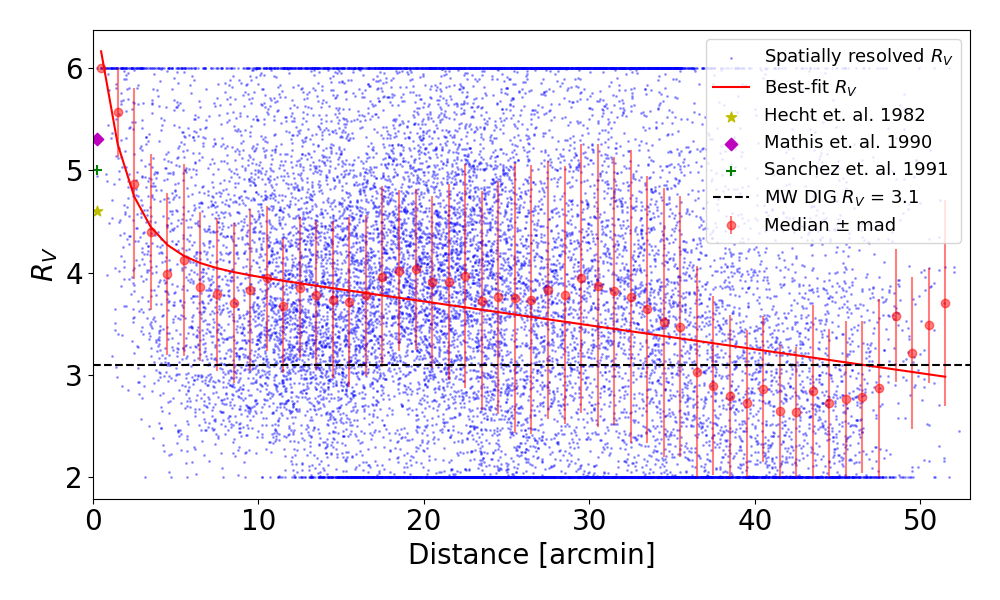

****** 0.24835846131755882


In [6]:

# Load your FITS table
data = Table.read(base_dir+f'spatially_resolved_rv_ebv_1.1.2dev0.fits')

# Load radial distance array (in arcmin) for each spaxel
RA = data['RA']
Dec = data['Dec']

# Assuming Her 36 binary as center for RA and Dec coordinates
ra_hms = '18 03 40.3201232304'
dec_dms = '-24 22 42.857540472'

coord = SkyCoord(ra=ra_hms, dec=dec_dms, unit=(u.hourangle, u.deg), frame='icrs')

# Converting RA and Dec to degrees using Skycoord
ra_center_deg = coord.ra.deg
dec_center_deg = coord.dec.deg

distance_to_nebula = 1250 # in parsecs

# Calculatinf the angular distance in degrees and also adjusting RA by the cosine of the declination
angular_distances_deg = np.sqrt(
    ((RA - ra_center_deg) * np.cos(np.radians(dec_center_deg)))**2 +
    (Dec - dec_center_deg)**2)

# Angular distance from degrees to parsecs
# Degrees to radians: radians = degrees * (np.pi / 180). Then, distance in parsecs = distance_to_nebula * angular_distance_in_radians
angular_distances_rad = angular_distances_deg * (np.pi / 180)
distances_parsec = distance_to_nebula * angular_distances_rad


radius = angular_distances_deg*60 #distances_parsec  # or in pc: data['distance_pc']
rv = data['Rv']

# Bin data in radial annuli
dr = 1 #arcmins, other option: 1'

median_rv = []
mad_rv = []

# Define the bin edges in parsecs 
bin_edges_parsec = np.arange(0, np.max(radius), dr)
bin_centers_parsec = (bin_edges_parsec[:-1] + bin_edges_parsec[1:]) / 2

# Getting indices of the bins to which each value in distance belongs
bin_indices_parsec = np.digitize(angular_distances_deg*60, bins=bin_edges_parsec)  


for i in range(1, len(bin_edges_parsec)):

    bin_mask = bin_indices_parsec == i

    if np.sum(bin_mask) > 0:
        median_rv.append(np.nanmedian(rv[bin_mask]))
        mad_rv.append(mad(rv[bin_mask]))
        #std_error_parsec.append(np.sqrt(np.sum(flux_error[bin_mask]**2)) / np.sum(bin_mask)) OR
        #std_error_parsec.append(mad(flux[bin_mask]))
        
    else:
        median_rv.append(np.nan)
        mad_rv.append(np.nan)


# Convert lists to arrays
median_rv = np.array(median_rv)
mad_rv = np.array(mad_rv)

print("median_rv:", median_rv)
print("bin_centers_parsec:", bin_centers_parsec)


# Mask valid bins (exclude NaNs)
valid = ~np.isnan(median_rv)

# Define hybrid model: exponential + linear
def exp_linear(r, A, r0, B, C):
    return A * np.exp(-r / r0) + B * r + C

# Initial guess for parameters: [A, r0, B, C]
p0 = [3.1, 2.0, -0.1, 3.0]

# Fit only to valid (non-NaN) data
popt, pcov = curve_fit(exp_linear, bin_centers_parsec[valid], median_rv[valid], p0=p0)

print(f" {popt[0]} * exp(-r / {popt[1]}) + {popt[2]} * r + {popt[3]}")
# Evaluate fit
fit_rv = exp_linear(bin_centers_parsec, *popt)

plt.figure(figsize=(10, 6))
plt.rcParams.update({'font.size': 20,
                     'legend.fontsize': 13,})

# Plotting
plt.scatter(radius, rv, s = 5, marker ='.', c ='b', alpha =0.3, label =r'Spatially resolved $R_V$')
plt.errorbar(bin_centers_parsec, median_rv, yerr=mad_rv, fmt='o', color='r', alpha =0.5, label='Median ± mad')
plt.plot(bin_centers_parsec, fit_rv, color='r', label=r'Best-fit $R_V$')

plt.scatter(0.28, 4.6, s=60, marker='*', color='y', label='Hecht et. al. 1982')
plt.scatter(0.28, 5.3, s=40, marker='D', color='m', label='Mathis et. al. 1990')
plt.scatter(0.28, 5.0, s=60, marker='+', color='g', label='Sanchez et. al. 1991')
plt.hlines(y=3.1, xmin = 0, xmax = 53, color='k', linestyle='--', label=r'MW DIG $R_V$ = 3.1')

plt.xlabel('Distance [arcmin]')
plt.ylabel(r'$R_V$')
#plt.title(r'Radial Profile of $R_V$')
#plt.grid(alpha=0.3)
plt.xlim(0, 53) 

plt.legend()
plt.tight_layout()
plt.savefig(base_dir+f'Rv_radial_fit_dr_{dr}arcmin_1.1.2dev0.png', dpi =200)
plt.show()

print('******', np.nanmin(radius))


In [11]:
plt.close()

In [ ]:
# Rv(r) annd spatially resolved E(B-V) map

No such comm: f36e34d07aeb49f896f6343dbfcf7863


In [12]:

######################### On spatially resolved spectra, last modified Jun 30th, 25 #####################

def extinction_curve(model, wavelength, Rv, Ebv):

    # Initializing the F99 extinction model, just as an example
    extinction_model = model(Rv)
    k_lambda = extinction_model(wavelength * u.AA)  
    return k_lambda * Ebv

# theoretical Balmer decrements 
balmer_theoretical = {

    'Hk':   [],
    'Hi':   [],
    'He':   [],
    'Hd':   [],
    'Hg':   [],
    'Hb':   [],
    'Ha':   [],
    'P11':  [],
    'P10':  [],
    'P9' :  []
                }

ratios = pyneb_ratio(8000, 120)  # integrated Te and ne: 8320, 120

# Assign ratios to the balmer_theoretical dictionary
keys = list(balmer_theoretical.keys())
for i, key in enumerate(keys):
    balmer_theoretical[key] = ratios[i]

print('Balmer theoretical ratios:', balmer_theoretical)

with fits.open(base_dir+f'lagoon_combined_multi_normalized_sframe_spectra_obs_flux_table_1.1.2dev_jul8.fits') as hdu:

    data = hdu[1].data

# Wavelengths of the Balmer lines 
    
wavelengths = {
    'Hk': data['HI3750_wave0'],
    'Hi': data['HI3771_wave0'],
    'He': data['HI3835_wave0'],
    'Hd': data['HI4102_wave0'], 
    'Hg': data['Hgm4340_wave0'], 
    'Hb': data['Hb4861_wave0'], 
    'Ha': data['Ha6563_wave0'],
    'P11': data['HI8863_wave0'],
    'P10': data['HI9015_wave0'],
    'P9' : data['HI9229_wave0'] 
                }

# Observed Balmer line fluxes 
observed_ratios = {

    'Hk':  data['HI3750_flux0']/(data['Hb4861_flux0']  ),   
    'Hi':  data['HI3771_flux0']/(data['Hb4861_flux0']  ),   
    'He':  data['HI3835_flux0']/(data['Hb4861_flux0']  ),
    'Hd':  data['HI4102_flux0']/(data['Hb4861_flux0']  ),
    'Hg':  data['Hgm4340_flux0']/(data['Hb4861_flux0'] ),
    'Hb':  data['Hb4861_flux0']/(data['Hb4861_flux0']  ),
    'Ha':  data['Ha6563_flux0']/(data['Hb4861_flux0']  ),
    'P11': data['HI8863_flux0']/(data['Hb4861_flux0']  ),
    'P10': data['HI9015_flux0']/(data['Hb4861_flux0']  ),
    'P9' : data['HI9229_flux0']/(data['Hb4861_flux0']  )
                  
                  }

# divide obs_ratios and modeled ratios with the theoretical values at 0 extinction
# calculate err on obs_ratios and plot it using errorbar func, overplot it with modeled obs_ratios

error_obs_ratios = {

    'Hk' : observed_ratios['Hk' ] * np.sqrt((data['HI3750_flux0_err']/data['HI3750_flux0'])**2 + (data['Hb4861_flux0_err']/data['Hb4861_flux0'])**2),
    'Hi' : observed_ratios['Hi' ] * np.sqrt((data['HI3771_flux0_err']/data['HI3771_flux0'])**2 + (data['Hb4861_flux0_err']/data['Hb4861_flux0'])**2),
    'He' : observed_ratios['He' ] * np.sqrt((data['HI3835_flux0_err']/data['HI3835_flux0'])**2 + (data['Hb4861_flux0_err']/data['Hb4861_flux0'])**2),
    'Hd' : observed_ratios['Hd' ] * np.sqrt((data['HI4102_flux0_err']/data['HI4102_flux0'])**2 + (data['Hb4861_flux0_err']/data['Hb4861_flux0'])**2),
    'Hg' : observed_ratios['Hg' ] * np.sqrt((data['Hgm4340_flux0_err']/data['Hgm4340_flux0'])**2 + (data['Hb4861_flux0_err']/data['Hb4861_flux0'])**2),
    'Hb' : observed_ratios['Hb' ] * np.sqrt(2) * (data['Hb4861_flux0_err'] / data['Hb4861_flux0']),
    'Ha' : observed_ratios['Ha' ] * np.sqrt((data['Ha6563_flux0_err']/data['Ha6563_flux0'])**2 + (data['Ha6563_flux0_err']/data['Ha6563_flux0'])**2),
    'P11': observed_ratios['P11'] * np.sqrt((data['HI8863_flux0_err']/data['HI8863_flux0'])**2 + (data['Hb4861_flux0_err']/data['Hb4861_flux0'])**2),
    'P10': observed_ratios['P10'] * np.sqrt((data['HI9015_flux0_err']/data['HI9015_flux0'])**2 + (data['Hb4861_flux0_err']/data['Hb4861_flux0'])**2),
    'P9' : observed_ratios['P9' ] * np.sqrt((data['HI9229_flux0_err']/data['HI9229_flux0'])**2 + (data['Hb4861_flux0_err']/data['Hb4861_flux0'])**2)

            }

#mask
included_lines = ['Hd', 'Hg', 'Hb', 'P11', 'P9']  


mask = [line in included_lines for line in wavelengths.keys()]

# Convert the ratios to arrays
obs_ratios = np.array([observed_ratios[line] for line in wavelengths])[mask]
err_obs_ratios = np.array([error_obs_ratios[line] for line in wavelengths])[mask]
theor_ratios = np.array([balmer_theoretical[line] for line in wavelengths])[mask]
wave_array = np.array([wavelengths[line] for line in wavelengths])[mask]

theo_ratios = np.tile(theor_ratios, (len(data), 1)).T

# Initialize empty lists to store results for all spaxels
ra_list = []
dec_list = []
ebv_list = []
ebv_err_list = []
rv_list = []
rv_err_list = []
chi_sqr_list = []

############################ Calling fit_ebv function ###############################

def model_fixed_rv(wave, ebv, fixed_rv):
    return model_function(wave, fixed_rv, ebv)


# Model function to fit
def model_function(wavelength, Rv, Ebv):

    # Model for the observed line ratios affected by dust extinction
    try:
        extinction_factor = np.array([10**(-0.4 * (extinction_curve(F99, wave, Rv, Ebv) - 
                            extinction_curve(F99, wavelengths['Hb'][0], Rv, Ebv))) 
                            for wave in wavelength])
    
    except Exception as e:
        print("Error in extinction factor calculation:", e)
        return np.full_like(wavelength, np.nan)
    
    #modeled_ratios = theo_ratios * extinction_factor
    modeled_ratios = theo_ratios_spaxel * extinction_factor  
    
    return modeled_ratios

# Fit function
def fit_ebv(Rv):
    
    #print('We are using Rv opttimal param:', Rv)
    p0 = (1.0)

    # Fit only E(B‒V) while keeping Rv fixed
    def fit_func(wave, ebv):
        return model_fixed_rv(wave, ebv, Rv)

    popt, pcov, infodict, mesg, ier = curve_fit(
        fit_func,
        wave_array_spaxel,
        obs_ratios_spaxel.flatten(),
        p0=p0,
        sigma=err_obs_ratios_spaxel.flatten(),
        absolute_sigma=True,
        bounds=(0, 5),
        full_output=True
    )

    # Chi-squared
    fvec = infodict['fvec']
    chi_sqr = np.sum(fvec**2) / (len(theo_ratios_spaxel) - 1)

    best_fit_ebv = popt[0]
    best_fit_ebv_err = np.sqrt(pcov[0, 0])
    modeled_ratios_spaxel = fit_func(wave_array_spaxel, best_fit_ebv)

    return Rv, best_fit_ebv, best_fit_ebv_err, chi_sqr

for i in range(len(data)):

    ra = data['RA'][i]
    dec = data['Dec'][i]
    wave_array_spaxel = wave_array[:, i]
    obs_ratios_spaxel = obs_ratios[:, i]
    err_obs_ratios_spaxel = err_obs_ratios[:, i]
    theo_ratios_spaxel = theo_ratios[:, i]

    # Assuming Her 36 binary as center for RA and Dec coordinates
    ra_hms = '18 03 40.3201232304'
    dec_dms = '-24 22 42.857540472'

    coord = SkyCoord(ra=ra_hms, dec=dec_dms, unit=(u.hourangle, u.deg), frame='icrs')

    # Converting RA and Dec to degrees using Skycoord
    ra_center_deg = coord.ra.deg
    dec_center_deg = coord.dec.deg
    distance_to_nebula = 1250  # in parsecs

    # Calculatinf the angular distance in degrees and also adjusting RA by the cosine of the declination
    angular_distances_deg = np.sqrt(
        ((ra - ra_center_deg) * np.cos(np.radians(dec_center_deg)))**2 +
        (dec - dec_center_deg)**2)

    # Angular distance from degrees to parsecs
    # Degrees to radians: radians = degrees * (np.pi / 180). Then, distance in parsecs = distance_to_nebula * angular_distance_in_radians
    angular_distances_rad = angular_distances_deg * (np.pi / 180)
    distances_parsec = distance_to_nebula * angular_distances_rad
    angular_dist_arcmin = angular_distances_deg *60

    if angular_dist_arcmin > 0.65:

        # 2.7560223445080365 * exp(-r / 2.0848973433056113) + -0.02036209356314973 * r + 3.986440135262606, oct 13th 2025
        #  rv = 2.75602 * np.exp(-1*angular_dist_arcmin / 2.0849) + -0.02036 * angular_dist_arcmin + 3.9864  
        rv = 2.6626 * np.exp(-1*angular_dist_arcmin / 1.704) + -0.0233 * angular_dist_arcmin + 4.1849  # 1.1.2dev0, oct 30th

        #rv = 2.91967 * np.exp(-1*angular_dist_arcmin / 1.9121) + -0.008713 * angular_dist_arcmin + 3.7816, 

    else:
        rv = 6


    best_fit_rv, best_fit_ebv, best_fit_ebv_err, best_chi = fit_ebv(rv)

    #print('angular_distances_arcmin, rv:', angular_dist_arcmin, rv)

    ra_list.append(ra)
    dec_list.append(dec)
    ebv_list.append(best_fit_ebv)
    ebv_err_list.append(best_fit_ebv_err)
    rv_list.append(best_fit_rv)
    chi_sqr_list.append(best_chi)

output_table = Table(
    [ra_list, dec_list, rv_list, ebv_list, ebv_err_list, chi_sqr_list],
    names=('RA', 'Dec', 'Rv', 'Ebv', 'Ebv_err', 'chi_sqr'))


output_table.write(base_dir+f'rv(r)_ebv_1.1.2dev0.fits', overwrite=True)



Balmer theoretical ratios: {'Hk': 0.030319625089174285, 'Hi': 0.03940712978109057, 'He': 0.07244370228325539, 'Hd': 0.25666289298156547, 'Hg': 0.46528555506712715, 'Hb': 1.0, 'Ha': 2.915023447508534, 'P11': 0.014074110265375604, 'P10': 0.018810714350823002, 'P9': 0.025980611450412902}


In [ ]:
#################### dust correction usimg E(B-V) map crreated at an spatially resolved Rv values #######################

In [13]:
with fits.open(base_dir+f'rv(r)_ebv_1.1.2dev0.fits') as hdul:
    data = hdul[1].data
    
def calculate_extinction(rv_array, line_wavelength):
    
    A_line = np.zeros(len(data))
    A_line_err = np.zeros(len(data))

    for j, rv in enumerate(rv_array):

        extinction_model = F99(Rv=rv)
        f_line = extinction_model(line_wavelength * u.AA)
        A_line[j] = data['Ebv'][j] * f_line
        A_line_err[j] = data['Ebv_err'][j] * f_line


    return A_line, A_line_err

def dust_corr_all_ratios(filename, lines_to_correct):
    
    with fits.open(filename) as hdul:
        table = hdul[1].data
    
    # Prepare new columns
    new_columns = []
    for key in table.columns.names:
        if "flux" in key or "RA" in key or "Dec" in key:
            obs_col_name = f"obs_{key}"
            new_columns.append(fits.Column(name=obs_col_name, format="D", array=table[key]))

    # Loop over lines to correct
    offsets = [0, 14.19, 23.38, 31.69, 34.65, 41.97, 43.68, 51.01, 54.47, 69.07]

    for line_label in lines_to_correct:

        for i in range(10):  # Correcting up to 10 components

            flux_column = f"{line_label}_flux{i}"
            flux_err_column = f"{line_label}_flux{i}_err"
            wave_column = f"{line_label}_wave{i}"

            if flux_column in table.columns.names:

                if line_label == 'NII_OII':
                    line_wavelength = 4607.16 + offsets[i]  # Using the above provided offsets

                elif line_label == '[OIII]4363':
                    line_wavelength = 4363.2 

                else:
                    line_wavelength = (
                    table[wave_column][0])
                
                if line_wavelength == 0:
                    int_flux_col_name = f"int_{flux_column}"
                    int_flux_err_col_name = f"int_{flux_err_column}"
                    new_columns.append(fits.Column(name=int_flux_col_name, format="D", array=table[flux_column]))
                    new_columns.append(fits.Column(name=int_flux_err_col_name, format="D", array=table[flux_err_column]))

                else:

                    A_line, A_line_err = calculate_extinction(data['Rv'], line_wavelength)
                    observed_flux = table[flux_column]
                    observed_flux_err = table[flux_err_column]

                    intrinsic_flux = observed_flux * 10 ** (0.4 * A_line)
                    intrinsic_flux_err = observed_flux_err * 10 ** (0.4 * A_line)

                    # Calculate intrinsic flux error
                    #error = np.sqrt(
                    #    (observed_flux_err / observed_flux) ** 2 + 
                    #    (0.4 * A_line_err * np.log(10)) ** 2)         # A_line_error should be considered but now we neglect ebv_err
                    # intrinsic_flux_err = intrinsic_flux * error

                    #intrinsic_flux_err = observed_flux_err * 10 ** (0.4 * A_line)

                    int_flux_col_name = f"int_{flux_column}"
                    int_flux_err_col_name = f"int_{flux_err_column}"
                    new_columns.append(fits.Column(name=int_flux_col_name, format="D", array=intrinsic_flux))
                    new_columns.append(fits.Column(name=int_flux_err_col_name, format="D", array=intrinsic_flux_err))


    # Add E(B-V) columns
    new_columns.append(fits.Column(name="E(B-V)", format="D", array=data['Ebv'] * np.ones(len(table))))
    new_columns.append(fits.Column(name="E(B-V)_err", format="D", array=data['Ebv_err'] * np.ones(len(table))))
    new_columns.append(fits.Column(name="Rv", format="D", array=data['Rv'] * np.ones(len(table))))
    new_columns.append(fits.Column(name="A", format="D", array= A_line))
    #new_columns.append(fits.Column(name="A_err", format="D", array= A_line_err))
    
    #print('mean , median:', np.nanmean(data['E(B-V)']), np.nanmedian(data['E(B-V)']), 'err:', np.nanmean(data['E(B-V)_err']), np.nanmedian(data['E(B-V)_err']))

    # Write to a new FITS file
    cols = fits.ColDefs(new_columns)
    hdu = fits.BinTableHDU.from_columns(cols)
    output_filename = base_dir+f'lagoon_obs_corr_flux_table_1.1.2dev0_jul8.fits'
    hdu.writeto(output_filename, overwrite=True)
    print(f"File saved: {output_filename}")


# Input
filename = base_dir+f'lagoon_combined_multi_normalized_sframe_spectra_obs_flux_table_1.1.2dev_jul8.fits'

lines_to_correct = {

    'HI3750': [3750.15],
    'HI3771': [3770.63],
    'HI3835': [3835.38], 
    'HI4102': [4101.74], 
    'Ha6563': [6562.8],
    'Hb4861': [4861.32],
    'Hgm4340': [4340.463] ,
    'NII_OII' : [4607.16] ,
    ##'[SII]4069': [4068.6] ,
    '[SII]6717': [6716.44],
    '[SII]6731': [6730.82],
    '[NII]5755': [5754.64],
    '[NII]6548': [6548.04],
    '[NII]6584': [6583.46],
    '[OIII]4363': [4363.2],
    '[OIII]4959': [4958.91],
    '[OIII]5007': [5006.84],
    '[OII]3726': [3726.03],
    '[OII]7320': [7319.99],
    '[OII]7330': [7330],
    '[ClIII]5517':[5517.71],
    '[ClIII]5537':[5537.88],
    'CII4267':[4267.09],
    'HI8863': [8862.78],
    'HI9015': [9014.91],
    'HI9229': [9229.01],
    '[SIII]6312': [6312.1],
    '[SIII]9069': [9068.6],
    '[SIII]9531': [9530.6]
    }

dust_corr_all_ratios(filename, lines_to_correct)


File saved: /Volumes/amrita/LVM/m8_oct30_25_final_for_paper/resolved/lagoon_obs_corr_flux_table_1.1.2dev0_jul8.fits


In [10]:
# Rv varyinng from 5.6 to 3.8

In [11]:
plt.clos:

SyntaxError: invalid syntax (1180573098.py, line 1)

In [ ]:
################################ Date: Sept 30th, 24 ################################

def dust_corr(filename, lines_to_correct):

    
    with fits.open(filename ) as hdul:
        table = hdul[1].data

    # Initializing the F99 extinction model
    extinction_model = F99(Rv=3.1)

    # Retrieving Ha and Hb line fluxes and their errors
    Ha_flux = table['Ha6563_flux0']
    Hb_flux = table['Hb4861_flux0']
    Ha_flux_err = table['Ha6563_flux0_err']
    Hb_flux_err = table['Hb4861_flux0_err']

    # Observed wavelengths of Hα and Hβ
    Ha_wavelength = 6562.8 * u.AA
    Hb_wavelength = 4861.32 * u.AA

    # Intrinsic Ha/Hb ratio
    I_intrinsic = 2.86

    # Calculate observed Ha/Hb ratio
    I_observed = Ha_flux / Hb_flux
    I_observed_err = I_observed * np.sqrt((Ha_flux_err / Ha_flux) ** 2 + (Hb_flux_err / Hb_flux) ** 2)

    # Calculate color excess
    fHa = extinction_model(Ha_wavelength)
    fHb = extinction_model(Hb_wavelength)

    E_B_V = 2.5 * np.log10(I_observed / I_intrinsic) / (fHb - fHa)

    # Error on E(B-V)
    log_err_term = (1 / np.log(10)) * (I_observed_err / I_observed)
    E_B_V_err = np.abs((2.5 / (fHb - fHa)) * log_err_term)

    # Create lists to store new columns
    new_columns = []

    # Copy and rename observed columns
    for key in table.columns.names:
        if 'flux' in key or 'wave' in key or 'RA' in key or 'Dec' in key:
            obs_col_name = f"obs_{key}"
            new_columns.append(fits.Column(name=obs_col_name, format='D', array=table[key]))

    # Loop over lines to correct
    offsets = [0, 14.19, 23.38, 31.69, 34.65, 41.97, 43.68, 51.01, 54.47, 69.07]

    for line_label in lines_to_correct.items():

        for i in range(10):  # Correcting up to 10 components (0 to 10)


            flux_column = f'{line_label}_flux{i}'
            flux_err_column = f'{line_label}_flux{i}_err'
            wave_column = f'{line_label}_wave{i}'

            if flux_column in table.columns.names:

                print('hello!')

                if line_label == 'NII_OII':
                    line_wavelength = 4607.16 + offsets[i]  # Using the above provided offsets
                else:
                    line_wavelength = table[wave_column][0]  # Using the observed wavelength from the table
                
                if line_wavelength != 0:  # Check for zero wavelength

                    # Copying the column without correction
                    #int_flux_col_name = f"int_{flux_column}"
                    #int_flux_err_col_name = f"int_{flux_err_column}"
                    #new_columns.append(fits.Column(name=int_flux_col_name, format='D', array=table[flux_column]))
                    #new_columns.append(fits.Column(name=int_flux_err_col_name, format='D', array=table[flux_err_column]))

                #else:
                    f_line = extinction_model(line_wavelength * u.AA)
                    A_line = E_B_V * f_line
                    A_line_err = E_B_V_err * f_line


                    observed_flux = table[flux_column]
                    observed_flux_err = table[flux_err_column]

                    intrinsic_flux = observed_flux * 10 ** (0.4 * A_line)
                    intrinsic_flux_err = intrinsic_flux * np.sqrt((observed_flux_err / observed_flux) ** 2 + (0.4 * A_line_err * np.log(10)) ** 2)

                    print(A_line, observed_flux, intrinsic_flux)

                    # Store corrected fluxes and errors
                    int_flux_col_name = f"int_{flux_column}"
                    int_flux_err_col_name = f"int_{flux_err_column}"
                    new_columns.append(fits.Column(name=int_flux_col_name, format='D', array=intrinsic_flux))
                    new_columns.append(fits.Column(name=int_flux_err_col_name, format='D', array=intrinsic_flux_err))

    
    # Add E(B-V) and its error to the new columns
    new_columns.append(fits.Column(name='E_B_V', format='D', array=E_B_V))
    new_columns.append(fits.Column(name='E_B_V_err', format='D', array=E_B_V_err))

    # Create FITS columns for the new data
    cols = fits.ColDefs(new_columns)

    # Create a BinTableHDU object with the columns and write it to a FITS file
    hdu = fits.BinTableHDU.from_columns(cols)
    hdu.writeto('/Users/amritasingh/LVM_lagoon_outputs/condition2_cont/test_lagoon_FOV_obs_corr_flux_table_nov26.fits', overwrite=True)

# Variable radial bins
filename = '/Users/amritasingh/LVM_lagoon_outputs/condition2_cont/lagoon_sframe_obs_flux_table_nov26.fits'

lines_to_correct = {
    'NII_OII' : [4607.16],
    #'[SII]4069': [4068.6], 
    '[SII]6717': [6716.44],
    '[SII]6731': [6730.82],

    #'[NII]5755': [5754.64],
    ##'[NII]6548': [6548.04],  
    #'[NII]6584': [6583.46],
#
    '[OIII]4363': [4363.2],
    '[OIII]4959': [4958.91],
    '[OIII]5007': [5006.84],
#
    '[OII]3726': [3726.03],
    '[OII]7320': [7319.99],
    '[OII]7330': [7330],
#
    'Ha6563': [6562.8],
    'Hb4861': [4861.32],
    'Hgm4340': [4340.46],
    'HI3750': [3750.15],
    'HI3771': [3770.63],
    'HI3835': [3835.38],
    'HI4102': [4101.74],
    'HI8863': [8862.78],
    'HI9015': [9014.91],
    'HI9229': [9229.01],

    ##'OII4638': [4638.86],
    #
    #'[ClIII]5517':[5517.71],
    #'[ClIII]5537':[5537.88] 
    }

dust_corr(filename, lines_to_correct)


In [ ]:
################################ Date: Sept 30th, 24 for integrated spectrum ################################

def dust_corr(filename, lines_to_correct):
    
    with fits.open(filename) as hdul:
        table = hdul[1].data

    # Wavelength range (in Angstroms), this fits file is opened just to read the wavelength, no other use
    with fits.open('/Users/amritasingh/LVM_lagoon_outputs/integrated_spectrum/lagoon_integrated_spectrum_SB.fits') as hdu:
        wave = hdu[1].data['wave'].flatten()
    wavelengths = wave * u.AA

    # Initializing the F99 extinction model
    extinction_model = F99(Rv=3.1)
    ext = extinction_model(wavelengths)

    # Retrieving Ha and Hb line fluxes and their errors
    Ha_flux = table['Ha6563_flux0']
    Hb_flux = table['Hb4861_flux0']
    Ha_flux_err = table['Ha6563_flux0_err']
    Hb_flux_err = table['Hb4861_flux0_err']

    # Observed wavelengths of Ha abd Hb
    Ha_wavelength = 6562.8 * u.AA
    Hb_wavelength = 4861.32 * u.AA

    # Intrinsic Ha/Hb ratio
    I_intrinsic = 2.86

    # Observed Ha/Hb ratio
    I_observed = Ha_flux / Hb_flux
    I_observed_err = I_observed * np.sqrt((Ha_flux_err / Ha_flux) ** 2 + (Hb_flux_err / Hb_flux) ** 2)

    # Color excess
    fHa = extinction_model(Ha_wavelength)
    fHb = extinction_model(Hb_wavelength)
    E_B_V = 2.5 * np.log10(I_observed / I_intrinsic) / (fHb - fHa)
    E_B_V_err = 2.5 / (I_observed * np.log(10) * (fHb - fHa)) * I_observed_err

    # Lists to store new columns
    new_columns = []

    # Copy and rename observed columns
    for key in table.columns.names:
        if 'flux' in key or 'distance' in key:
            obs_col_name = f"obs_{key}"
            new_columns.append(fits.Column(name=obs_col_name, format='D', array=table[key]))

    # Loop over lines to correct
    offsets = [0, 14.19, 23.38, 31.69, 34.65, 41.97, 43.68, 51.01, 54.47, 69.07]

    for line_label, wavelengths in lines_to_correct.items():
        for i in range(10):  # Correcting up to 10 components (0 to 10)

            flux_column = f'{line_label}_flux{i}'
            flux_err_column = f'{line_label}_flux{i}_err'
            wave_column = f'{line_label}_wave{i}'

            if flux_column in table.columns.names:

                if line_label == 'NII_OII':
                    line_wavelength = 4607.16 + offsets[i]  # Using the above provided offsets
                else:
                    line_wavelength = table[wave_column][0]  # Using the observed wavelength from the table
                
                if line_wavelength == 0:  # Check for zero wavelength

                    # Copying the column without correction
                    int_flux_col_name = f"int_{flux_column}"
                    int_flux_err_col_name = f"int_{flux_err_column}"
                    new_columns.append(fits.Column(name=int_flux_col_name, format='D', array=table[flux_column]))
                    new_columns.append(fits.Column(name=int_flux_err_col_name, format='D', array=table[flux_err_column]))

                else:
                    
                    f_line = extinction_model(line_wavelength * u.AA)
                    A_line = E_B_V * f_line
                    A_line_err = E_B_V_err * f_line

                    observed_flux = table[flux_column]
                    observed_flux_err = table[flux_err_column]
                    intrinsic_flux = observed_flux * 10 ** (0.4 * A_line)
                    intrinsic_flux_err = intrinsic_flux * np.sqrt((observed_flux_err / observed_flux) ** 2 + (0.4 * A_line_err * np.log(10)) ** 2)

                    # Store corrected fluxes and errors
                    int_flux_col_name = f"int_{flux_column}"
                    int_flux_err_col_name = f"int_{flux_err_column}"
                    new_columns.append(fits.Column(name=int_flux_col_name, format='D', array=intrinsic_flux))
                    new_columns.append(fits.Column(name=int_flux_err_col_name, format='D', array=intrinsic_flux_err))

    # Add E(B-V) and its error to the new columns
    new_columns.append(fits.Column(name='E_B_V', format='D', array=E_B_V))
    #new_columns.append(fits.Column(name='E_B_V_err', format='D', array=E_B_V_err))

    # Create FITS columns for the new data
    cols = fits.ColDefs(new_columns)

    # Create a BinTableHDU object with the columns and write it to a FITS file
    hdu = fits.BinTableHDU.from_columns(cols)
    hdu.writeto('/Users/amritasingh/LVM_lagoon_outputs/integrated_spectrum/SB_lagoon_integrated_obs_corr_flux_table.fits', overwrite=True)

# Variable radial bins
filename = '/Users/amritasingh/LVM_lagoon_outputs/integrated_spectrum/SB_lagoon_integrated_obs_flux_table.fits'

lines_to_correct = {
    'HI3750': [3750.15],
    'HI3835': [3835.38], 
    'HI4102': [4101.74], 
    'HI9229': [9229.01],
    'Ha6563': [6562.8],
    'Hb4861': [4861.32],
    'Hgm4340': [4340.463] ,
    'NII_OII' : [4607.16] ,
    '[SII]4069': [4068.6] ,
    '[SII]6717': [6716.44],
    '[SII]6731': [6730.82],
    '[NII]5755': [5754.64],
    '[NII]6548': [6548.04],
    '[NII]6584': [6583.46],
    '[OIII]4363': [4363.2],
    '[OIII]4959': [4958.91],
    '[OIII]5007': [5006.84],
    '[OII]3726': [3726.03],
    '[OII]7320': [7319.99],
    '[OII]7330': [7330],
    '[ClIII]5517':[5517.71],
    '[ClIII]5537':[5537.88],
    'HI9229': [9229.01],
    '[SIII]6312': [6312.1],
    '[SIII]9069': [9068.6],
    '[SIII]9531': [9530.6],
     }

dust_corr(filename, lines_to_correct)

In [ ]:
################################ Dust correction function ################################

def dust_corr(filename, lines_to_correct):
    with fits.open(filename ) as hdul:
        table = hdul[1].data

    # Ensure the number of entries matches the original table
    num_entries = len(table)

    # Wavelength range (in Angstroms), this fits file is opened just to read the wavelength, no other use
    with fits.open('/Users/amritasingh/LVM_lagoon_outputs/integrated_spectrum/lagoon_integrated_spectrum.fits') as hdu:
        wave = hdu[1].data['wave'].flatten()
    wavelengths = wave * u.AA

    # Initializing the F99 extinction model
    extinction_model = F99(Rv=3.1)
    ext = extinction_model(wavelengths)

    # Retrieving Hα and Hβ line fluxes and their errors
    Ha_flux = table['Ha6563_flux0']
    Hb_flux = table['Hb4861_flux0']
    Ha_flux_err = table['Ha6563_flux0_err']
    Hb_flux_err = table['Hb4861_flux0_err']

    # Observed wavelengths of Hα and Hβ
    Ha_wavelength = 6562.8 * u.AA
    Hb_wavelength = 4861.32 * u.AA

    # Intrinsic Hα/Hβ ratio
    I_intrinsic = 2.86

    # Calculate observed Hα/Hβ ratio
    I_observed = Ha_flux / Hb_flux
    I_observed_err = I_observed * np.sqrt((Ha_flux_err / Ha_flux) ** 2 + (Hb_flux_err / Hb_flux) ** 2)

    # Calculate color excess
    fHa = extinction_model(Ha_wavelength)
    fHb = extinction_model(Hb_wavelength)
    E_B_V = 2.5 * np.log10(I_observed / I_intrinsic) / (fHb - fHa)
    E_B_V_err = 2.5 / (I_observed * np.log(10) * (fHb - fHa)) * I_observed_err

    # Create lists to store new columns
    new_columns = []

    # Copy and rename observed columns
    for key in table.columns.names:
        if 'flux' in key or 'wave' in key or 'distance' in key:
            obs_col_name = f"obs_{key}"
            new_columns.append(fits.Column(name=obs_col_name, format='D', array=table[key]))

    # Loop over lines to correct
    offsets = [0, 2.95, 10.27, 11.98, 19.31, 22.77, 37.37]

    for line_label, wavelengths in lines_to_correct.items():
        for i in range(7):  # Correcting up to 7 components (0 to 6)

            flux_column = f'{line_label}_flux{i}'
            flux_err_column = f'{line_label}_flux{i}_err'
            wave_column = f'{line_label}_wave{i}'

            if flux_column in table.columns.names:

                if line_label == 'OII4638':
                    line_wavelength = 4638.86 + offsets[i]  # Use the provided offsets
                else:
                    line_wavelength = table[wave_column][0]  # Use the observed wavelength from the table
                
                if line_wavelength == 0:  # Check for zero wavelength
                    # Copying the column without correction
                    int_flux_col_name = f"int_{flux_column}"
                    int_flux_err_col_name = f"int_{flux_err_column}"
                    new_columns.append(fits.Column(name=int_flux_col_name, format='D', array=table[flux_column]))
                    new_columns.append(fits.Column(name=int_flux_err_col_name, format='D', array=table[flux_err_column]))
                else:
                    f_line = extinction_model(line_wavelength * u.AA)
                    A_line = E_B_V * f_line
                    A_line_err = E_B_V_err * f_line

                    observed_flux = table[flux_column]
                    observed_flux_err = table[flux_err_column]
                    intrinsic_flux = observed_flux * 10 ** (0.4 * A_line)
                    intrinsic_flux_err = intrinsic_flux * np.sqrt((observed_flux_err / observed_flux) ** 2 + (0.4 * A_line_err * np.log(10)) ** 2)

                    # Store corrected fluxes and errors
                    int_flux_col_name = f"int_{flux_column}"
                    int_flux_err_col_name = f"int_{flux_err_column}"
                    new_columns.append(fits.Column(name=int_flux_col_name, format='D', array=intrinsic_flux))
                    new_columns.append(fits.Column(name=int_flux_err_col_name, format='D', array=intrinsic_flux_err))

    # Add E(B-V) and its error to the new columns
    new_columns.append(fits.Column(name='E_B_V', format='D', array=E_B_V))
    new_columns.append(fits.Column(name='E_B_V_err', format='D', array=E_B_V_err))

    # Create FITS columns for the new data
    cols = fits.ColDefs(new_columns)

    # Create a BinTableHDU object with the columns and write it to a FITS file
    hdu = fits.BinTableHDU.from_columns(cols)
    hdu.writeto('/Users/amritasingh/LVM_lagoon_outputs/integrated_spectrum/SB_lagoon_integrated_obs_corr_flux_table.fits', overwrite=True)

# Variable radial bins
filename = '/Users/amritasingh/LVM_lagoon_outputs/condition2_cont/annular_binned/lagoon_4363_radbinned_observed_spectrum_var1_6_arcmins_table.fits'
#filename = '/Users/amritasingh/LVM_lagoon_outputs/integrated_spectrum/SB_lagoon_integrated_obs_flux_table'

lines_to_correct = {
'HI3750': [3750.15],
'HI3771': [3770.63],
'HI3835': [3835.38],
'HI4102': [4101.74],
'HI8863': [8862.78],
'HI9015': [9014.91],
'HI9229': [9229.01],
'Ha6563': [6562.8,],
'NII_OII' : [4607.16], 

'[SII]6717': [6716.44],
'[SII]6731': [6730.82],
'[NII]5755': [5754.64],
'[NII]6548': [6548.04],
'[NII]6584': [6583.46],
'[OIII]4363': [4363.2],
'[OIII]4959': [4958.91],
'[OIII]5007': [5006.84],
            
'[SIII]6312': [6312.1],
'[SIII]9069': [9068.6],
'[SIII]9531': [9530.6],
            
'[OII]3726': [3726.03],
'[OII]7320': [7319.99],
'[OII]7330': [7330],

'Hb4861' : [4861.32],
'Hgm4340': [4340.463] 

}

dust_corr(filename, lines_to_correct)


In [ ]:
################################### Original script #################################

In [ ]:
def dust_corr(filename):

    with fits.open(filename+'.fits') as hdul:
        header = hdul[1].header
        table = hdul[1].data


    # Define the wavelength range (in Angstroms)
    wavelengths = table['wave'].flatten()* u.AA

    # Initializing the F99 extinction model, Fitzpatrick (1999) extinction law
    extinction_model = F99(Rv=3.1)

    # Compute the extinction (A_lambda / A_V) for each wavelength
    ext = extinction_model(wavelengths)

    # Retrieving flux values from the table
    Ha_flux = table['Ha6563_flux']
    Hb_flux = table['Hb4861_flux']

    # Intrinsic Halpha/Hbeta ratio
    I_intrinsic = 2.86  # Case B recombination at T = 10000 K, ne = 10^2 - 10^3 cm-3 ?
    fHa = 0.76039132        
    fHb = 1.166        

    # Calculate observed Halpha/Hbeta ratio
    I_observed = Ha_flux / Hb_flux

    # Calculate color excess
    E_B_V = 2.5 * np.divide(np.log10(I_observed / I_intrinsic), (fHb-fHa))

    # Using formula: A_lambda = c*k(lamda)
    def A_lambda(c,f):
        # reddening law
        A = c*f
        print(f"extinction: {np.nanmedian(A)}")

        return A

    # Calculate A(lambda) 
    A = A_lambda(E_B_V, ext)
    # Read observed Flux
    F_observed = table['flux'].flatten()

    factor = 10 **(0.4*A)

    # Calculating intrinsic flux
    F_intrinsic = F_observed * factor

    plt.plot(wavelengths, F_observed, c ='black', label='Observed flux')
    plt.plot(wavelengths, F_intrinsic, c ='red', label='Intrinsic flux')
    #plt.xlim(6540, 6590)
    plt.legend()
    plt.show()

    print(f"E(B-V): {E_B_V}")

    #  In case I want to store the values creating a dictionary
    extinction_data = {
        'Wavelength (Angstroms)': wavelengths.value,
        'A_lambda / A_V': ext
                    }
    # Convert the dictionary to a FITS table
    col1 = fits.Column(name='wave', format='D', array=extinction_data['Wavelength (Angstroms)'])
    col2 = fits.Column(name='A_lambda/A_V', format='D', array=extinction_data['A_lambda / A_V'])
    cols = fits.ColDefs([col1, col2])
    hdu = fits.BinTableHDU.from_columns(cols)
    # Writing fits table
    hdu.writeto('/Users/amritasingh/LVM_lagoon_outputs/condition2_cont/mw_dust_extinction_curve.fits', overwrite=True)


(12401,)


In [ ]:
datadir = '/Users/amritasingh/LVM_lagoon_outputs/'
filename= datadir+'lagoon_integrated_spectrum_table'
dust_corr(filename)

In [ ]:

#Plotting the extinction curve:
#plt.plot(wavelengths, ext)
#plt.xlabel(r'$\lambda (\AA)$')
#plt.ylabel(r'$\frac{A_{\lambda}}{A_{V}}$')
#plt.show()


In [ ]:
try: